In [43]:
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Import custom components from your local files
from model import SparseCategoricalF1Score
from dataset import load_split

# --- Project Root Discovery ---
project_root = Path.cwd()
while not (project_root / ".git").exists():
    if project_root == project_root.parent:
        break
    project_root = project_root.parent

# --- Paths to data ---
wikiart_path = project_root / "data"
train_dir = wikiart_path / "train"
val_dir = wikiart_path / "validation"
test_dir = wikiart_path / "test"

# --- Check paths exist ---
for path in [train_dir, val_dir, test_dir]:
    if not path.exists():
        print(f"Warning: {path} does not exist!")

print(f"Project root: {project_root}")
print(f"WikiArt path: {wikiart_path}")

# --- Dataset parameters ---
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

Project root: c:\Users\verov\Downloads\DeepLearning-NOVAIMS2026
WikiArt path: c:\Users\verov\Downloads\DeepLearning-NOVAIMS2026\data


In [44]:
# Load datasets using your dataset.py logic
# For a Perceptron, we don't usually need heavy augmentation, so augment=False
train_ds, class_names = load_split(train_dir, IMG_SIZE, BATCH_SIZE, augment=False)
val_ds, _ = load_split(val_dir, IMG_SIZE, BATCH_SIZE, augment=False)
test_ds, _ = load_split(test_dir, IMG_SIZE, BATCH_SIZE, augment=False)

num_classes = len(class_names)
print(f"Loaded {num_classes} classes.")

Found 9326 files belonging to 23 classes.
Found 1992 files belonging to 23 classes.
Found 2022 files belonging to 23 classes.
Loaded 23 classes.


In [45]:
def build_perceptron(num_classes, img_size):
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(*img_size, 3)),
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])
    
    f1_metric = SparseCategoricalF1Score(num_classes=num_classes, name="f1_macro")
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=[f1_metric, "accuracy"]
    )
    return model

model = build_perceptron(num_classes, IMG_SIZE)

# Setup Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_f1_macro', 
        mode='max', 
        patience=5, 
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_perceptron_model.keras',
        monitor='val_f1_macro',
        mode='max',
        save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6
    )
]


history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks
)

Epoch 1/50


c:\Users\verov\OneDrive\Documents\anaconda\envs\Fall2526\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


292/292 ━━━━━━━━━━━━━━━━━━━━ 47s 158ms/step - accuracy: 0.3027 - f1_macro: 0.2011 - loss: 215686.7188 - val_accuracy: 0.0994 - val_f1_macro: 0.0079 - val_loss: 789968.3125 - learning_rate: 0.0010
Epoch 2/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 31s 106ms/step - accuracy: 0.2023 - f1_macro: 0.1127 - loss: 292183.3750 - val_accuracy: 0.0994 - val_f1_macro: 0.0079 - val_loss: 577894.3750 - learning_rate: 0.0010
Epoch 3/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 11s 37ms/step - accuracy: 0.2111 - f1_macro: 0.1223 - loss: 263539.0312 - val_accuracy: 0.0994 - val_f1_macro: 0.0079 - val_loss: 500325.0938 - learning_rate: 0.0010
Epoch 4/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.2379 - f1_macro: 0.1373 - loss: 236162.2812 - val_accuracy: 0.0994 - val_f1_macro: 0.0079 - val_loss: 490321.3750 - learning_rate: 0.0010
Epoch 5/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.2442 - f1_macro: 0.1538 - loss: 232394.3594 - val_accuracy: 0.0994 - val_f1_macro: 0.0079 - val_loss: 518999.3750 - l

In [46]:
print("\n--- Final Evaluation on Test Set ---")
results = model.evaluate(test_ds)
print(f"Test Loss: {results[0]:.4f}")
print(f"Test F1-Score: {results[1]:.4f}")


--- Final Evaluation on Test Set ---
64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.1954 - f1_macro: 0.1511 - loss: 55612.7070
Test Loss: 55612.7070
Test F1-Score: 0.1511


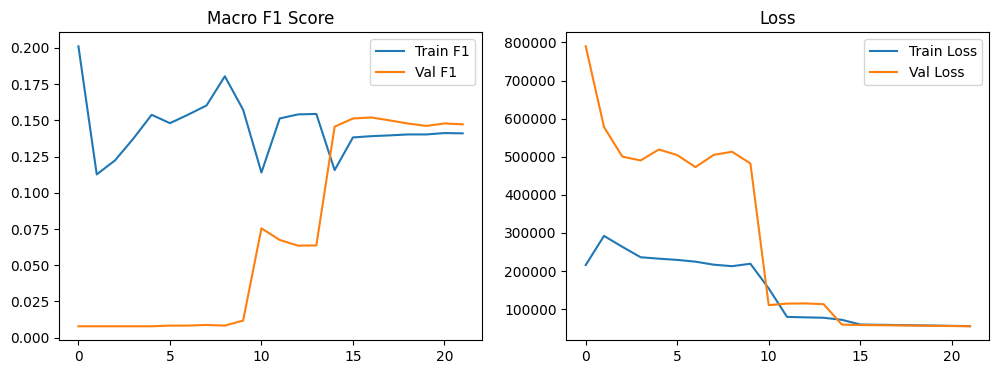

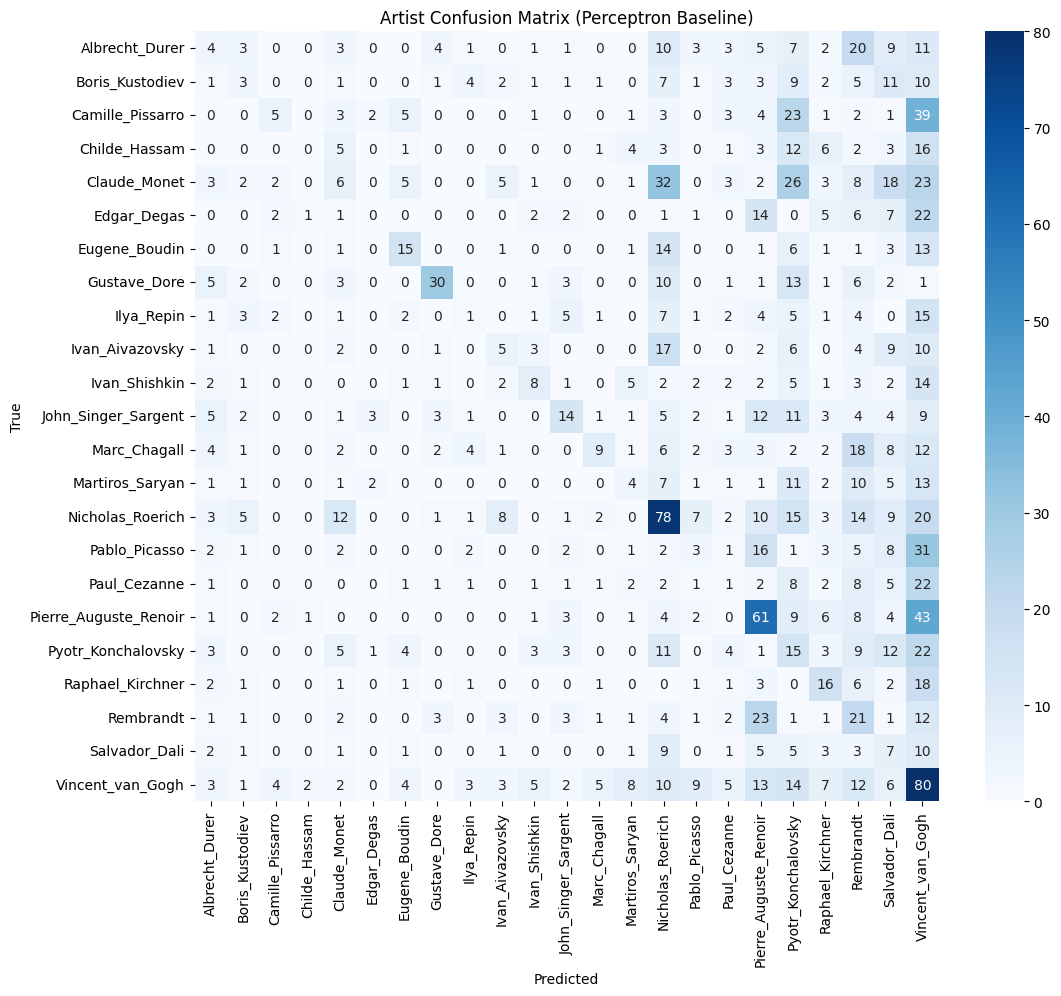

                       precision    recall  f1-score   support

       Albrecht_Durer       0.09      0.05      0.06        87
      Boris_Kustodiev       0.11      0.05      0.06        66
     Camille_Pissarro       0.28      0.05      0.09        93
        Childe_Hassam       0.00      0.00      0.00        57
         Claude_Monet       0.11      0.04      0.06       140
          Edgar_Degas       0.00      0.00      0.00        64
        Eugene_Boudin       0.38      0.26      0.31        58
         Gustave_Dore       0.64      0.38      0.48        79
           Ilya_Repin       0.05      0.02      0.03        56
      Ivan_Aivazovsky       0.16      0.08      0.11        60
        Ivan_Shishkin       0.28      0.15      0.19        54
  John_Singer_Sargent       0.33      0.17      0.23        82
         Marc_Chagall       0.39      0.11      0.17        80
      Martiros_Saryan       0.12      0.07      0.09        60
     Nicholas_Roerich       0.32      0.41      0.36  

In [47]:
# 1. Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['f1_macro'], label='Train F1')
plt.plot(history.history['val_f1_macro'], label='Val F1')
plt.title('Macro F1 Score')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

# 2. Confusion Matrix
y_true = []
y_pred = []

for imgs, labels in val_ds:
    preds = model.predict(imgs, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Artist Confusion Matrix (Perceptron Baseline)')
plt.show()

# 3. Final Metrics
print(classification_report(y_true, y_pred, target_names=class_names))